Judul: Klasifikasi kain defektif dan kain non defektif menggunakan fitur GLCM dengan membandingkan teknik preprocessing.
Percobaan 3 (Resize + Grayscale + Median Filter + Histogram Equalization + Sharpening + Dilasi)
Nama Anggota: Deswita Salsabila (F1D02410004)
Nama Anggota: Winona Andien Jihan Habbibah (F1D02410027)
Nama Anggota: Faiz Ahmad Tsaqib Wirawan (F1D02410043)
Nama Anggota: Dita Ayu Julita (F1D02410111)

Pada percobaan ketiga, preprocessing yang digunakan adalah Resize, Grayscale, Median Filter, Histogram Equalization, Sharpening, dan Dilasi. Selain Median Filter dan Histogram Equalization yang sudah digunakan pada Percobaan 2, ditambahkan Sharpening untuk mempertajam tepi dan detail tekstur pada citra kain, serta Dilasi untuk memperluas area terang sehingga fitur-fitur cacat menjadi lebih menonjol. Tujuannya adalah melihat apakah penambahan kedua proses ini dapat meningkatkan performa klasifikasi dibandingkan dengan percobaan sebelumnya.

In [32]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

DATA LOADING

In [33]:
data = []
labels = []
file_name = []

TARGET_SIZE = (128, 128)
DATASET_PATH = "dataset"

for sub_folder in os.listdir(DATASET_PATH):
    sub_folder_path = os.path.join(DATASET_PATH, sub_folder)
    if not os.path.isdir(sub_folder_path):
        continue
    for filename in os.listdir(sub_folder_path):
        img_path = os.path.join(sub_folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        img = img.astype(np.uint8)
        img = cv.resize(img, TARGET_SIZE)
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)
print(f"Total data: {len(data)}")
print(f"Label unik: {np.unique(labels)}")

Total data: 170
Label unik: ['defect' 'non_defect']


DATA UNDERSTANDING

Distribusi data:
  defect: 85 gambar
  non_defect: 85 gambar


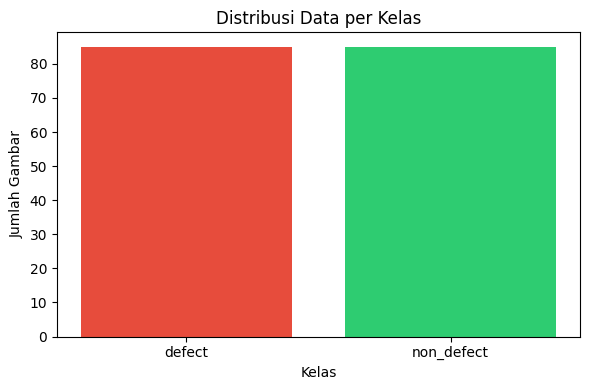

In [34]:
unique, counts = np.unique(labels, return_counts=True)
print("Distribusi data:")
for u, c in zip(unique, counts):
    print(f"  {u}: {c} gambar")

plt.figure(figsize=(6, 4))
plt.bar(unique, counts, color=['#e74c3c', '#2ecc71'])
plt.title('Distribusi Data per Kelas')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.tight_layout()
plt.show()

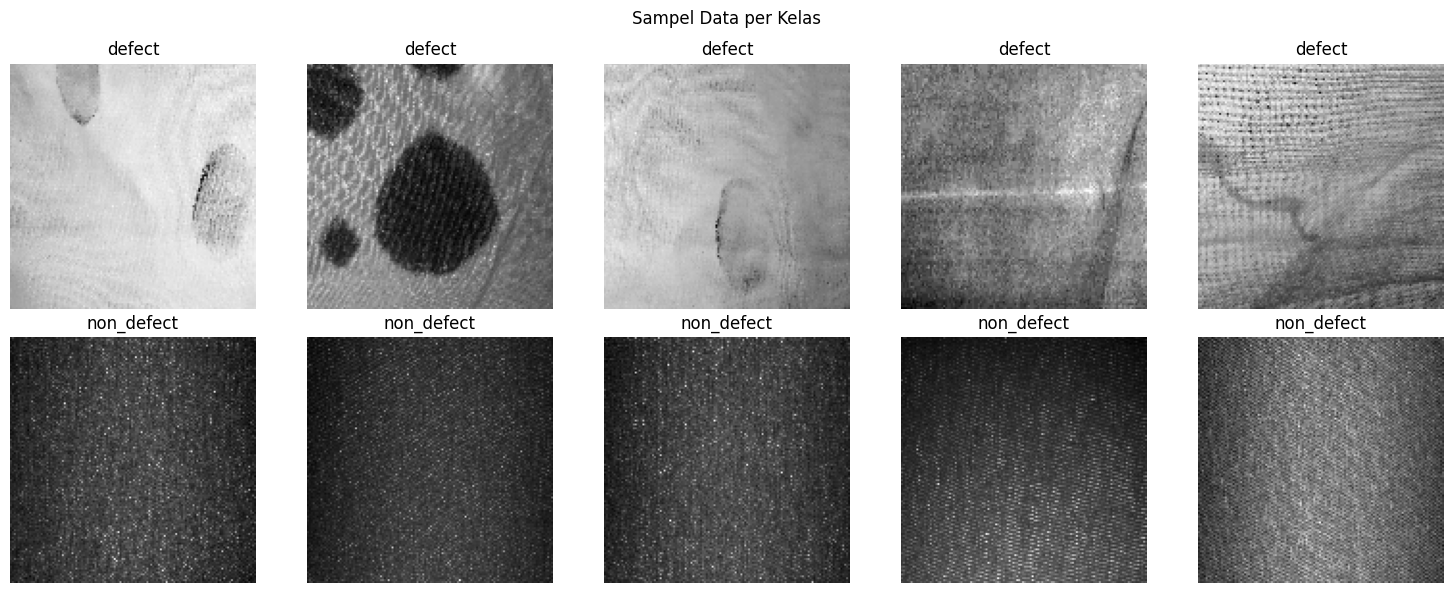

In [35]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, label in enumerate(np.unique(labels)):
    indices = np.where(labels == label)[0]
    for j in range(5):
        axes[idx][j].imshow(data[indices[j]], cmap='gray')
        axes[idx][j].set_title(label)
        axes[idx][j].axis('off')
plt.suptitle('Sampel Data per Kelas')
plt.tight_layout()
plt.show()

Dataset yang digunakan terdiri dari 170 citra kain, dengan 85 citra kelas defect dan 85 citra kelas non_defect. Jumlah data antar kelas sudah seimbang sehingga tidak diperlukan augmentasi data.

Terlihat bahwa kelas defect memiliki area cacat berupa bintik atau bercak gelap yang kontras dengan tekstur kain di sekitarnya, serta beberapa citra menunjukkan garis horizontal yang memperlihatkan kerusakan pada serat kain. Sementara itu, kelas non_defect menunjukkan tekstur kain yang lebih bagus tanpa adanya bercak.

DATA AUGMENTATION

In [36]:
print(f"Total data: {len(data)}")
print("Augmentasi tidak diperlukan karena jumlah data sudah mencukupi.")

Total data: 170
Augmentasi tidak diperlukan karena jumlah data sudah mencukupi.


DATA PREPARATION & DEFINE PREPROCESSING FUNCTION

In [54]:
def resize(image, target_size):
    return cv.resize(image, target_size)

def konvolusi(image, kernel):
    """
    Fungsi konvolusi manual untuk citra grayscale.
    """
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape
    center = k_h // 2

    hasil = np.zeros_like(image, dtype=np.float64)

    for i in range(center, img_h - center):
        for j in range(center, img_w - center):
            total = 0.0
            for k in range(k_h):
                for l in range(k_w):
                    total += image[i + k - center, j + l - center] * kernel[k, l]
            hasil[i, j] = total

    return np.clip(hasil, 0, 255).astype(np.uint8)

def sharpening(image):
    kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float64)
    result = konvolusi(image.astype(np.float64), kernel)
    return result

def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2

    hasil = np.zeros((height, width))

    for i in range(center, height - center):
        for j in range(center, width - center):

            if image[i, j] == 255:

                for k in range(k_height):
                    for l in range(k_width):

                        if kernel[k, l] == 1:
                            hasil[i + k - center, j + l - center] = 255

            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0

    return hasil

def prepro3(image):
    """
    Percobaan 3
    Preprocessing: Resize + Grayscale + Median Filter + Histogram Equalization + Sharpening + Dilasi
    Resize dan Grayscale sudah dilakukan saat load data.
    Pada fungsi ini dilakukan:
    1. Median Filter untuk mengurangi noise
    2. Histogram Equalization untuk meningkatkan kontras citra
    3. Sharpening untuk mempertajam tepi dan detail tekstur
    4. Dilasi untuk memperluas area terang sehingga fitur cacat lebih menonjol
    """
    image = image.astype(np.uint8)

    # Median Filter
    image = cv.medianBlur(image, 3)

    # Histogram Equalization
    image = cv.equalizeHist(image)

    # Sharpening
    image = sharpening(image)

    # Dilasi Grayscale
    kernel_dilasi = np.ones((3, 3), np.uint8)
    image = dilasi(image, kernel_dilasi).astype(np.uint8)

    return image

PREPROCESSING

In [38]:
dataPreprocessed = []
for i in range(len(data)):
    processed = prepro3(data[i])
    dataPreprocessed.append(processed)

dataPreprocessed = np.array(dataPreprocessed)
print(f"Shape data setelah preprocessing: {dataPreprocessed.shape}")

Shape data setelah preprocessing: (170, 128, 128)


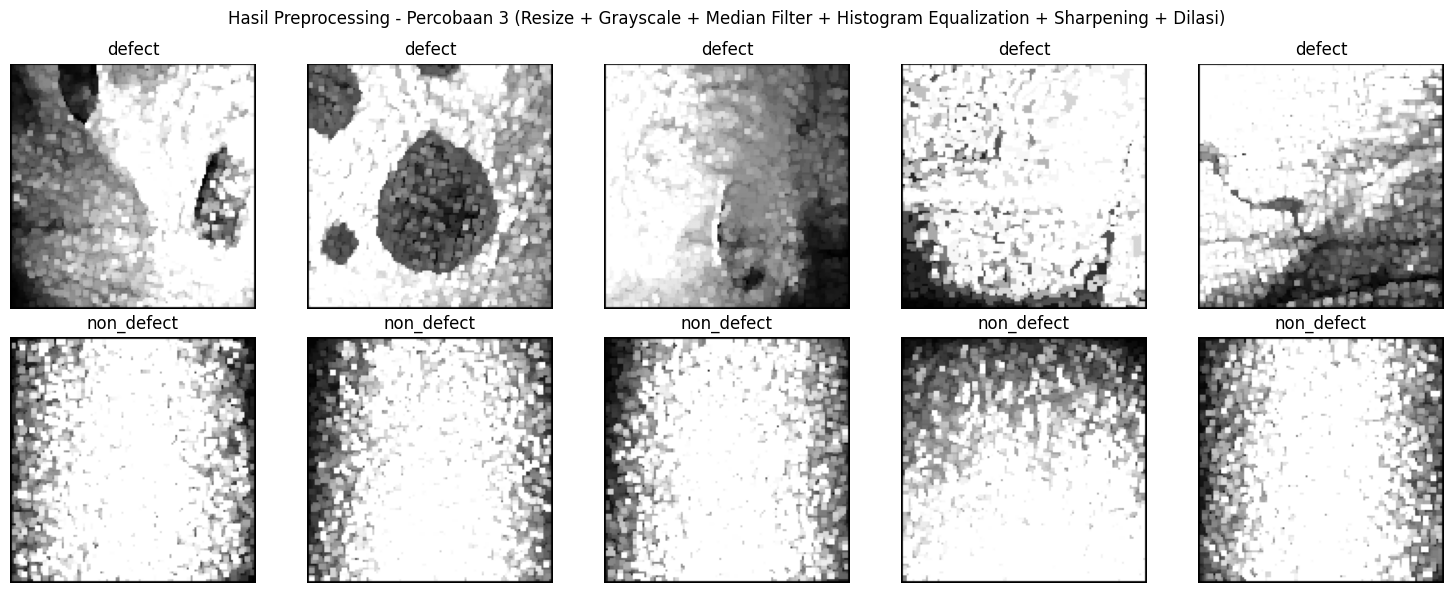

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
unique = np.unique(labels)
for idx, label in enumerate(unique):
    indices = np.where(labels == label)[0]
    for j in range(5):
        if j < len(indices):
            axes[idx, j].imshow(dataPreprocessed[indices[j]], cmap='gray')
            axes[idx, j].set_title(f'{label}')
            axes[idx, j].axis('off')
        else:
            axes[idx, j].axis('off')
plt.suptitle('Hasil Preprocessing - Percobaan 3 (Resize + Grayscale + Median Filter + Histogram Equalization + Sharpening + Dilasi)')
plt.tight_layout()
plt.show()

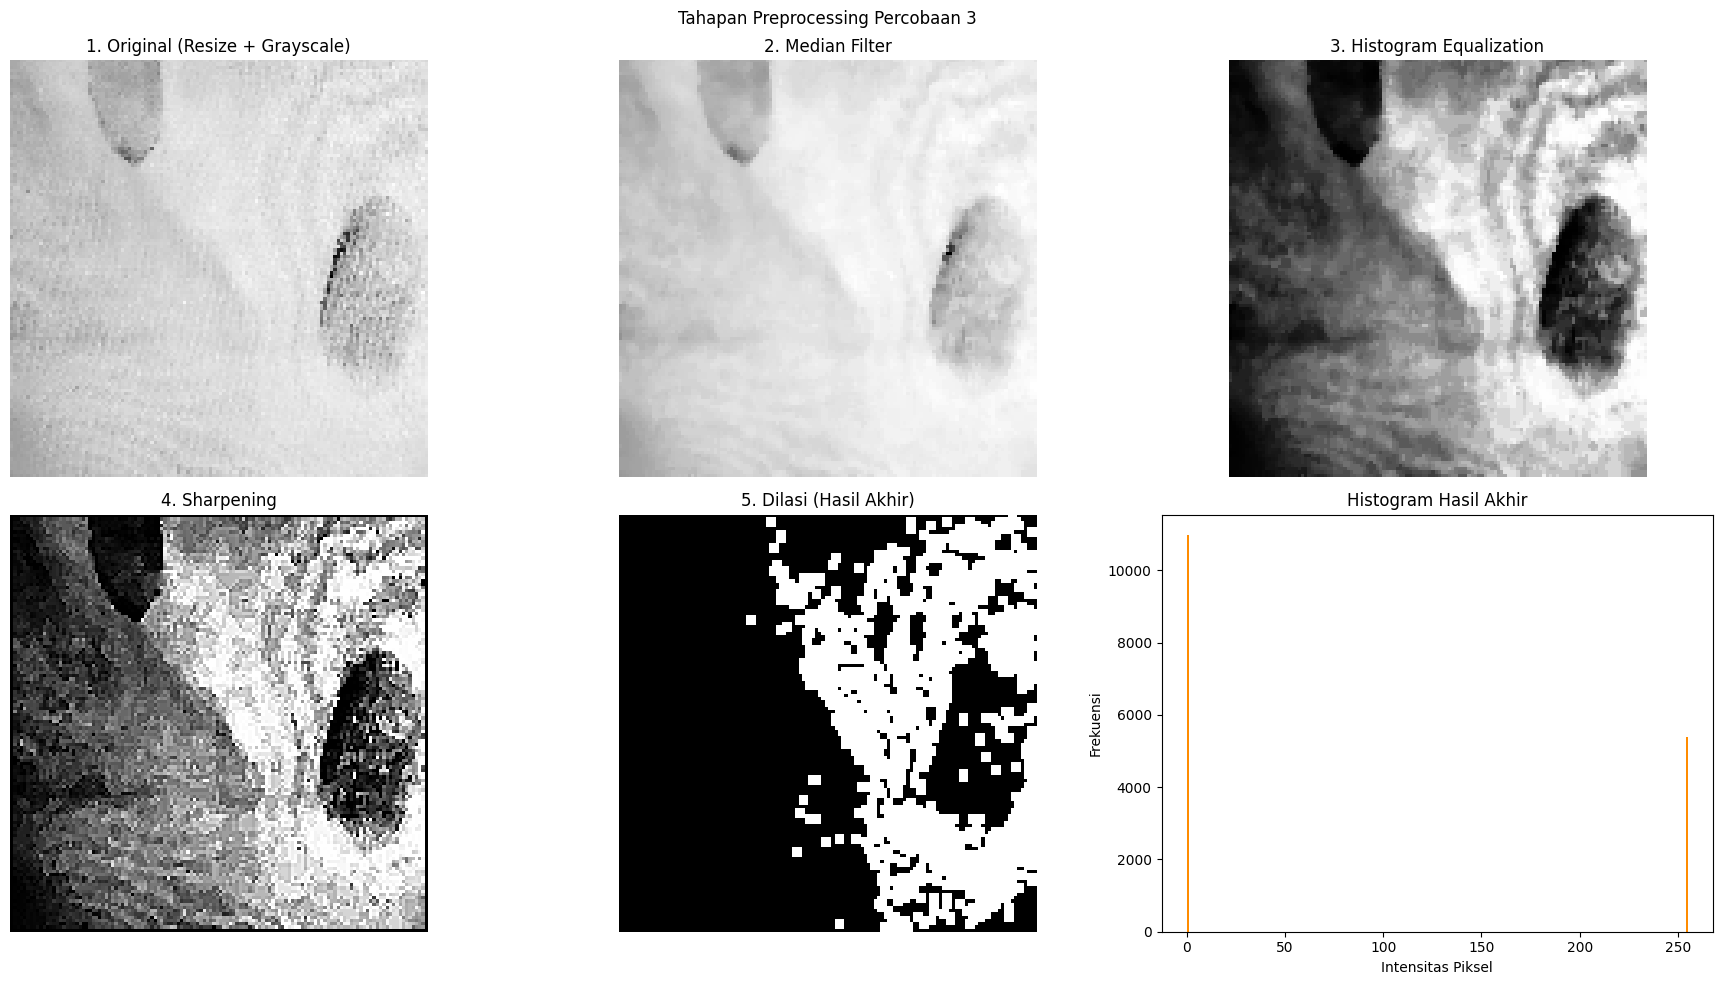

In [40]:
idx_contoh = 0

img_original = data[idx_contoh].astype(np.uint8)
img_median = cv.medianBlur(img_original, 3)
img_histeq = cv.equalizeHist(img_median)
img_sharp = sharpening(img_histeq)
kernel_dilasi = np.ones((3, 3), np.uint8)
img_dilasi = dilasi(img_sharp, kernel_dilasi).astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0][0].imshow(img_original, cmap='gray')
axes[0][0].set_title('1. Original (Resize + Grayscale)')
axes[0][0].axis('off')

axes[0][1].imshow(img_median, cmap='gray')
axes[0][1].set_title('2. Median Filter')
axes[0][1].axis('off')

axes[0][2].imshow(img_histeq, cmap='gray')
axes[0][2].set_title('3. Histogram Equalization')
axes[0][2].axis('off')

axes[1][0].imshow(img_sharp, cmap='gray')
axes[1][0].set_title('4. Sharpening')
axes[1][0].axis('off')

axes[1][1].imshow(img_dilasi, cmap='gray')
axes[1][1].set_title('5. Dilasi (Hasil Akhir)')
axes[1][1].axis('off')

axes[1][2].hist(img_dilasi.ravel(), bins=256, range=(0, 255), color='darkorange')
axes[1][2].set_title('Histogram Hasil Akhir')
axes[1][2].set_xlabel('Intensitas Piksel')
axes[1][2].set_ylabel('Frekuensi')

plt.suptitle('Tahapan Preprocessing Percobaan 3')
plt.tight_layout()
plt.show()

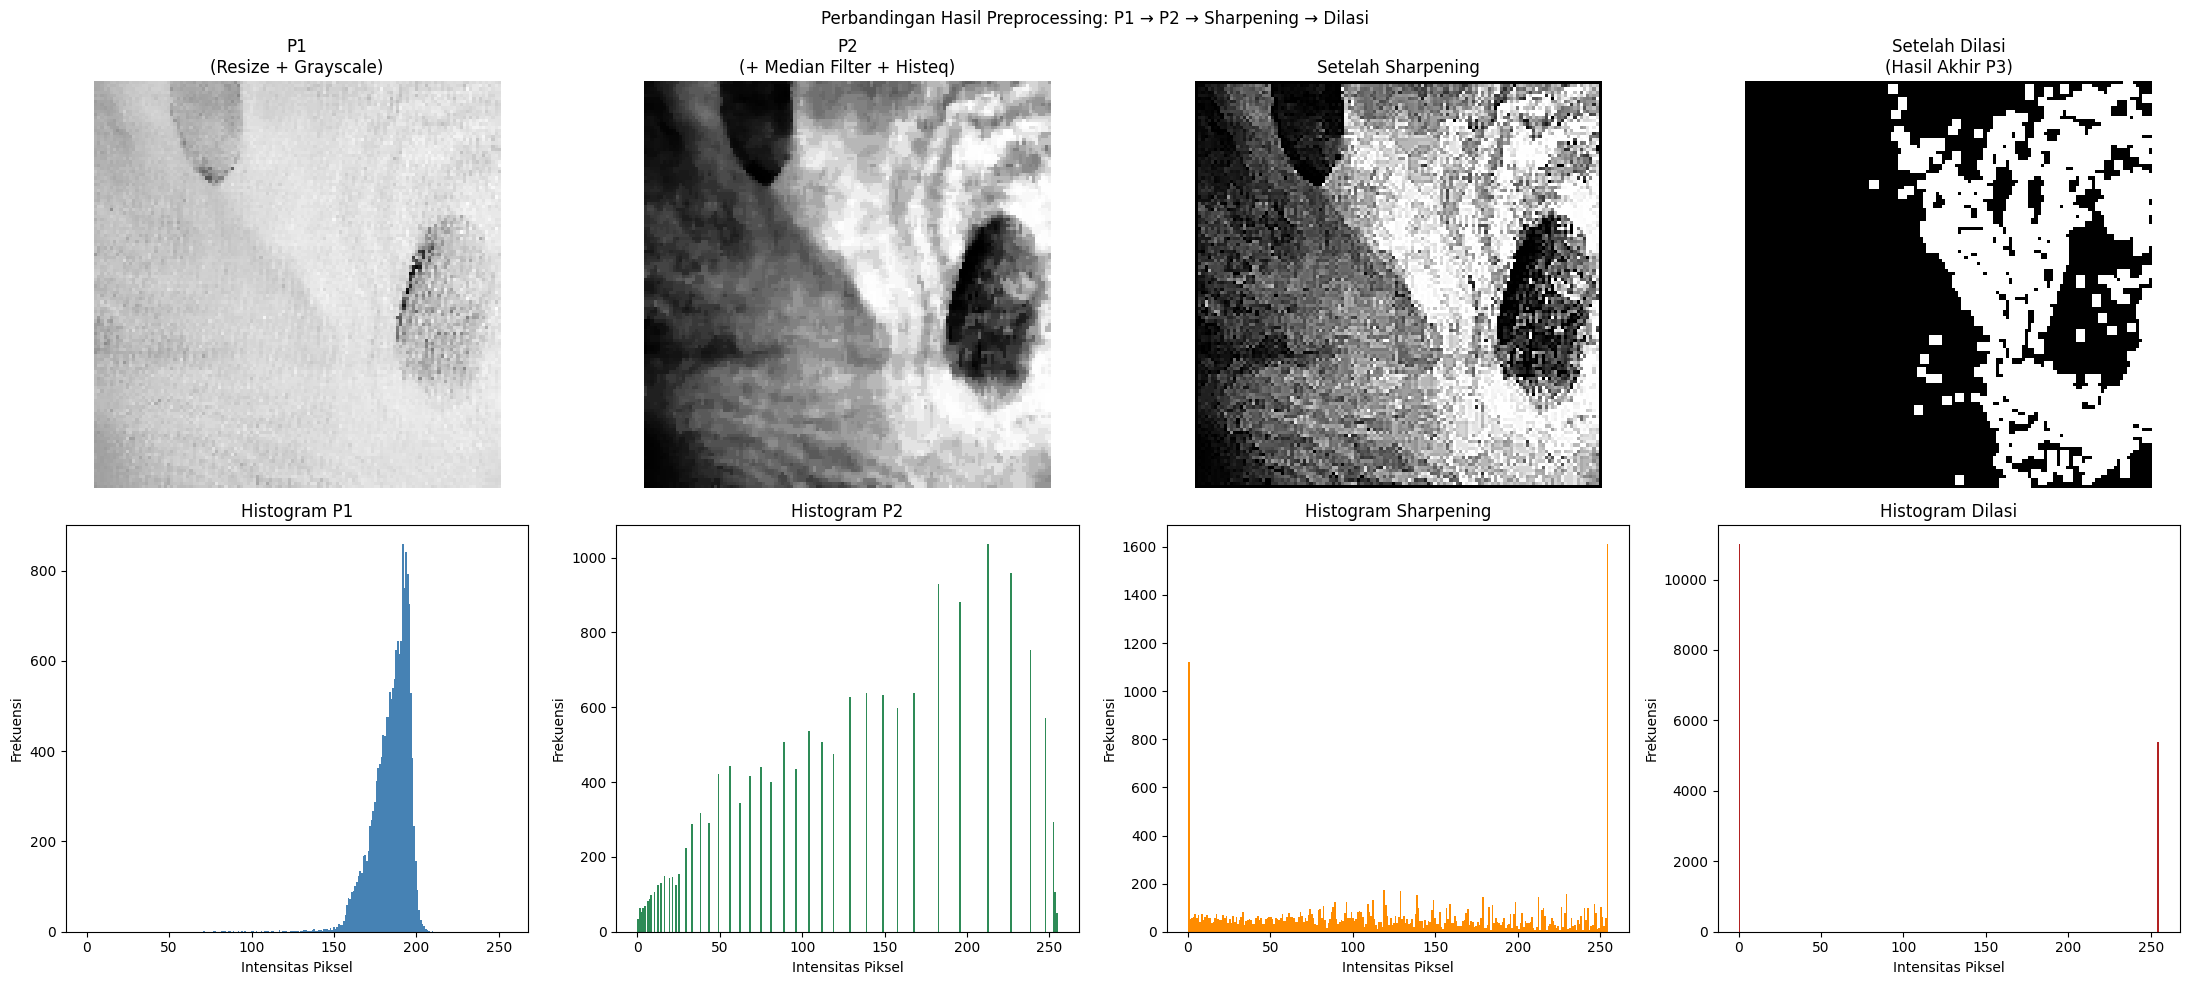

In [41]:
idx_contoh = 0

# P1: Resize + Grayscale
img_p1 = data[idx_contoh].astype(np.uint8)

# P2: Resize + Grayscale + Median Filter + Histogram Equalization
img_median = cv.medianBlur(img_p1, 3)
img_p2 = cv.equalizeHist(img_median)

# Setelah Sharpening
img_sharp = sharpening(img_p2)

# Setelah Dilasi (Hasil Akhir P3)
kernel_dilasi = np.ones((3, 3), np.uint8)
img_dilasi = dilasi(img_sharp, kernel_dilasi).astype(np.uint8)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

# Baris atas: citra
axes[0][0].imshow(img_p1, cmap='gray')
axes[0][0].set_title('P1\n(Resize + Grayscale)')
axes[0][0].axis('off')

axes[0][1].imshow(img_p2, cmap='gray')
axes[0][1].set_title('P2\n(+ Median Filter + Histeq)')
axes[0][1].axis('off')

axes[0][2].imshow(img_sharp, cmap='gray')
axes[0][2].set_title('Setelah Sharpening')
axes[0][2].axis('off')

axes[0][3].imshow(img_dilasi, cmap='gray')
axes[0][3].set_title('Setelah Dilasi\n(Hasil Akhir P3)')
axes[0][3].axis('off')

# Baris bawah: histogram
axes[1][0].hist(img_p1.ravel(), bins=256, range=(0, 255), color='steelblue')
axes[1][0].set_title('Histogram P1')
axes[1][0].set_xlabel('Intensitas Piksel')
axes[1][0].set_ylabel('Frekuensi')

axes[1][1].hist(img_p2.ravel(), bins=256, range=(0, 255), color='seagreen')
axes[1][1].set_title('Histogram P2')
axes[1][1].set_xlabel('Intensitas Piksel')
axes[1][1].set_ylabel('Frekuensi')

axes[1][2].hist(img_sharp.ravel(), bins=256, range=(0, 255), color='darkorange')
axes[1][2].set_title('Histogram Sharpening')
axes[1][2].set_xlabel('Intensitas Piksel')
axes[1][2].set_ylabel('Frekuensi')

axes[1][3].hist(img_dilasi.ravel(), bins=256, range=(0, 255), color='firebrick')
axes[1][3].set_title('Histogram Dilasi')
axes[1][3].set_xlabel('Intensitas Piksel')
axes[1][3].set_ylabel('Frekuensi')

plt.suptitle('Perbandingan Hasil Preprocessing: P1 → P2 → Sharpening → Dilasi')
plt.tight_layout()
plt.show()

FEATURE EXTRACTION

In [42]:
def glcm(image, derajat, distance=1):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut harus salah satu dari: 0, 45, 90, 135")
    matriks = graycomatrix(image, [distance], angles, 256, symmetric=True, normed=True)
    return matriks

In [43]:
def get_contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def get_dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def get_homogeneity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def get_energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def get_correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def get_ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def get_entropy(matriks):
    return entropy(matriks.ravel())

In [44]:
DISTANCES = [1, 2, 3, 4, 5]
ANGLES = [0, 45, 90, 135]

all_features = []

for i in range(len(dataPreprocessed)):
    img_features = {}
    for d in DISTANCES:
        for angle in ANGLES:
            mat = glcm(dataPreprocessed[i], angle, distance=d)
            img_features[f'Contrast_d{d}_a{angle}']     = get_contrast(mat)
            img_features[f'Dissimilarity_d{d}_a{angle}'] = get_dissimilarity(mat)
            img_features[f'Homogeneity_d{d}_a{angle}']  = get_homogeneity(mat)
            img_features[f'Energy_d{d}_a{angle}']       = get_energy(mat)
            img_features[f'Correlation_d{d}_a{angle}']  = get_correlation(mat)
            img_features[f'ASM_d{d}_a{angle}']          = get_ASM(mat)
            img_features[f'Entropy_d{d}_a{angle}']      = get_entropy(mat)
    all_features.append(img_features)

print(f"Jumlah fitur per gambar: {len(all_features[0])}")

Jumlah fitur per gambar: 140


In [45]:
dataTable = pd.DataFrame(all_features)
dataTable.insert(0, 'Filename', file_name)
dataTable.insert(1, 'Label', labels)
dataTable.to_csv('hasil_ekstraksi_3.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_3.csv')
hasilEkstrak.head()

,Filename,Label,Contrast_d1_a0,Dissimilarity_d1_a0,Homogeneity_d1_a0,Energy_d1_a0,Correlation_d1_a0,ASM_d1_a0,Entropy_d1_a0,Contrast_d1_a45,...,Correlation_d5_a90,ASM_d5_a90,Entropy_d5_a90,Contrast_d5_a135,Dissimilarity_d5_a135,Homogeneity_d5_a135,Energy_d5_a135,Correlation_d5_a135,ASM_d5_a135,Entropy_d5_a135
0,10_defect.jpg,defect,1166.131275,12.786909,0.622094,0.291257,0.910428,0.084830,5.947695,1920.453841,...,0.808133,0.060945,6.852190,3554.931777,36.061329,0.252876,0.230587,0.711499,0.053170,6.968163
1,11_defect.jpg,defect,1372.373031,15.690576,0.594379,0.285394,0.887403,0.081450,6.198531,2380.894662,...,0.712432,0.049366,7.136882,4507.328759,42.331621,0.229795,0.211013,0.621722,0.044526,7.225961
2,12_defect.jpg,defect,795.736097,9.535310,0.609874,0.204637,0.936705,0.041876,6.284045,1321.727943,...,0.895184,0.028664,7.271098,2005.615960,25.723400,0.204206,0.158741,0.832746,0.025199,7.413390
3,13_defect.jpg,defect,1862.495079,15.395792,0.754086,0.484961,0.824248,0.235188,3.022315,2959.834832,...,0.630979,0.152628,3.608266,4585.523023,37.127732,0.429582,0.386604,0.509371,0.149463,3.652168
4,14_defect.jpg,defect,1248.973794,13.568282,0.636695,0.360979,0.906153,0.130306,5.596011,2278.320541,...,0.751062,0.088668,6.459007,3498.130983,35.366415,0.318303,0.300479,0.725737,0.090288,6.474013


FEATURES SELECTION

Jumlah fitur sebelum seleksi: 140
Jumlah fitur setelah seleksi: 11


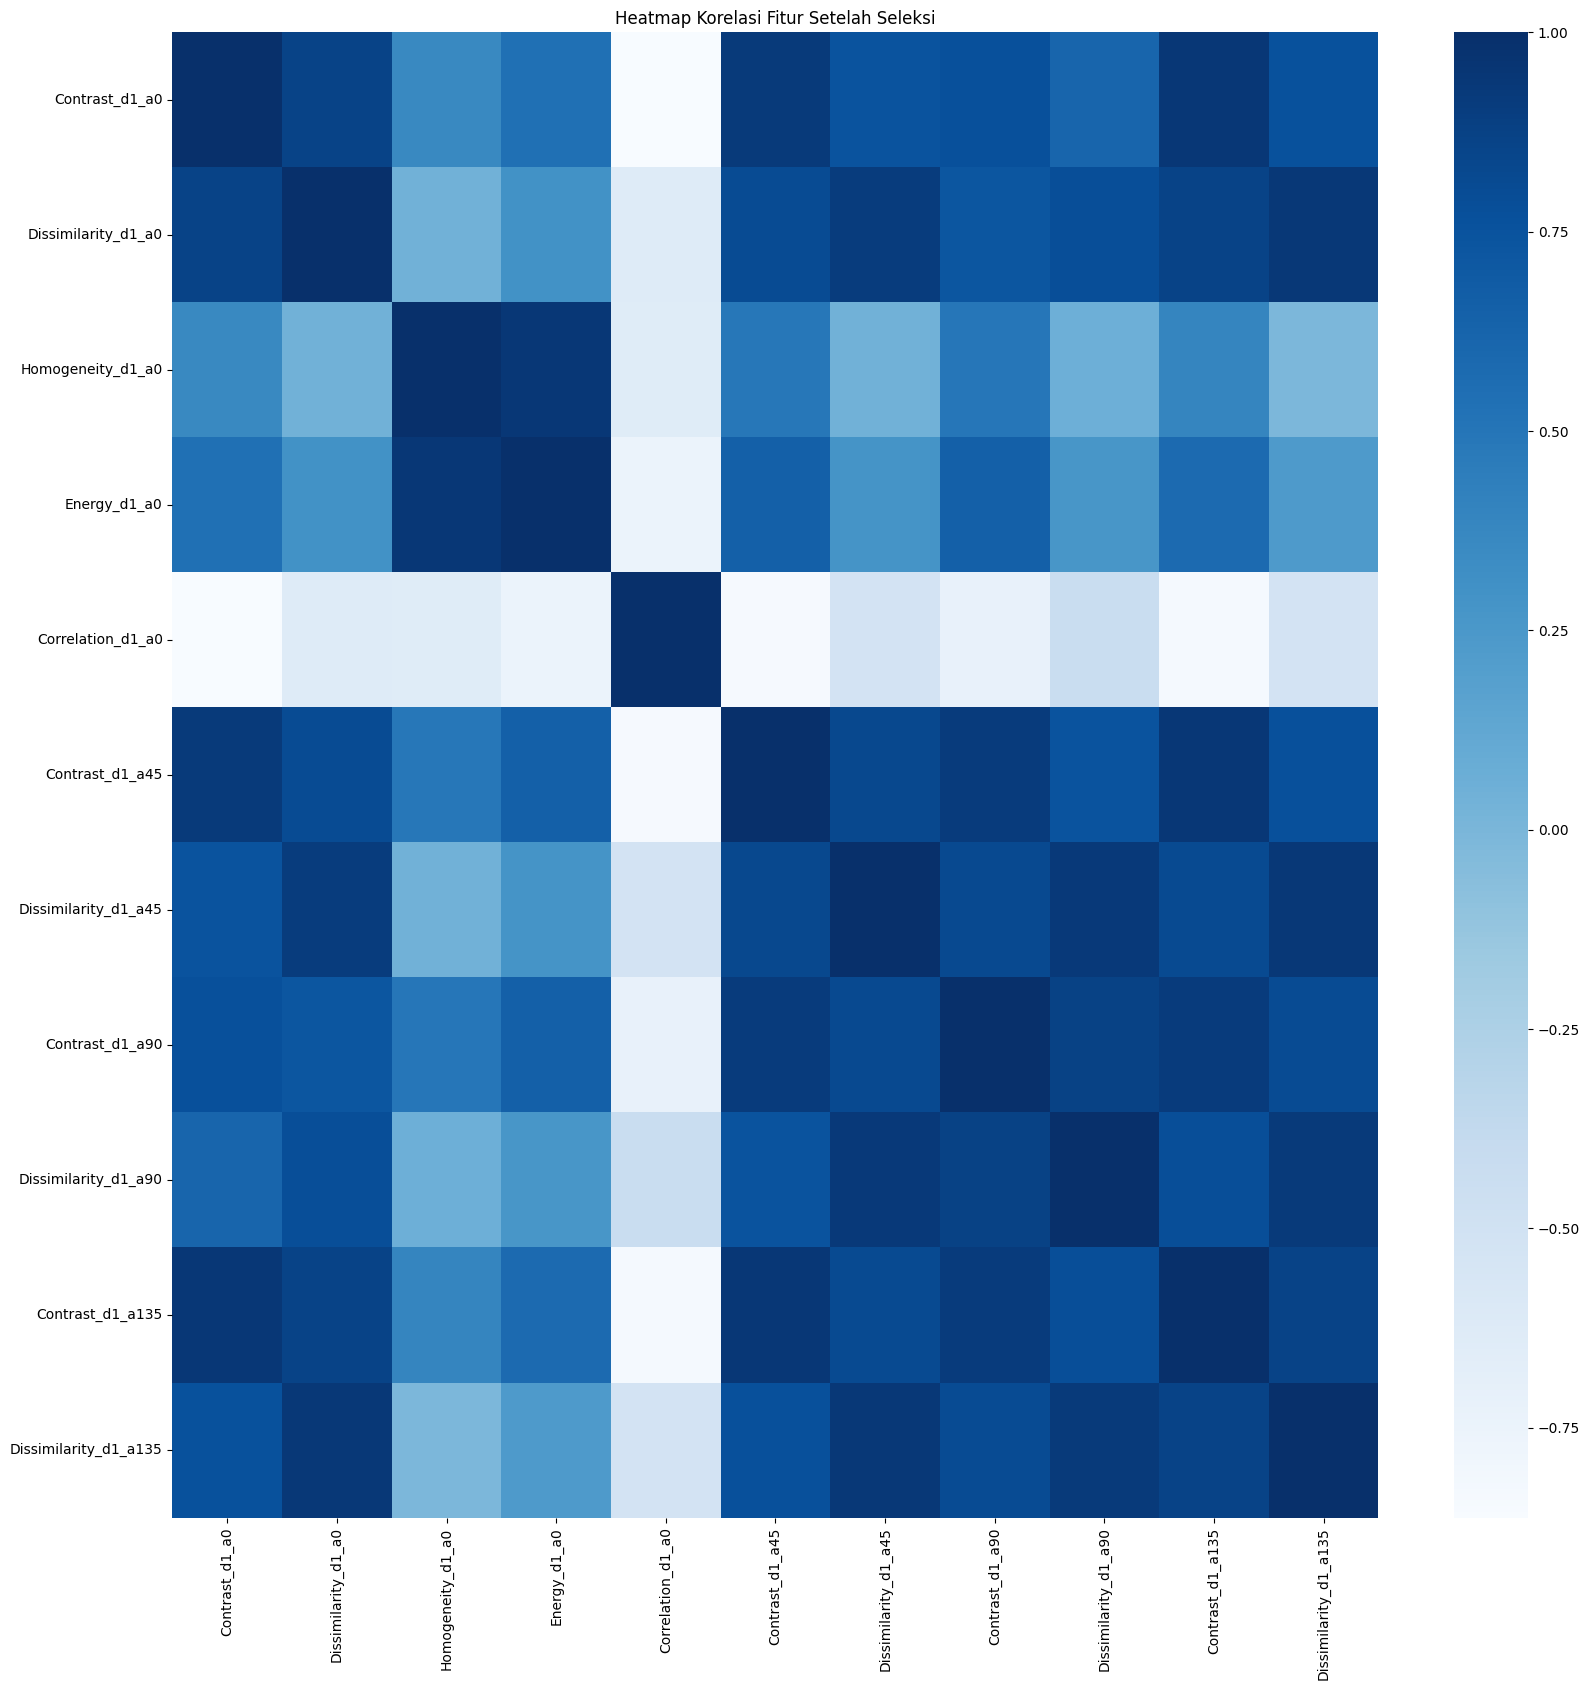

In [46]:
correlation_matrix = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)
for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if abs(correlation_matrix.iloc[i, j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Jumlah fitur sebelum seleksi: {len(hasilEkstrak.columns) - 2}")
print(f"Jumlah fitur setelah seleksi: {len(select)}")

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=False, cmap='Blues')
plt.title('Heatmap Korelasi Fitur Setelah Seleksi')
plt.tight_layout()
plt.show()

SPLITTING DATA

In [47]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (136, 11)
X_test shape:  (34, 11)


FEATURE NORMALIZATION

In [48]:
train_mean = X_train.mean()
train_std  = X_train.std()

X_train = (X_train - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std

print("Normalisasi selesai.")

Normalisasi selesai.


MODELING & DEFINE MODEL

In [49]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision: {precision_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'Recall   : {recall_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'F1-Score : {f1_score(y_true, y_pred, average="weighted"):.4f}')

rf  = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

TRAIN RANDOM FOREST CLASSIFIER

In [50]:
rf.fit(X_train, y_train)

print("------Training Set------")
generateClassificationReport(y_train, rf.predict(X_train))

print("\n------Testing Set------")
generateClassificationReport(y_test, rf.predict(X_test))

------Training Set------
              precision    recall  f1-score   support

      defect       0.98      0.98      0.98        65
  non_defect       0.99      0.99      0.99        71

    accuracy                           0.99       136
   macro avg       0.99      0.99      0.99       136
weighted avg       0.99      0.99      0.99       136

Accuracy : 0.9853
Precision: 0.9853
Recall   : 0.9853
F1-Score : 0.9853

------Testing Set------
              precision    recall  f1-score   support

      defect       0.90      0.90      0.90        20
  non_defect       0.86      0.86      0.86        14

    accuracy                           0.88        34
   macro avg       0.88      0.88      0.88        34
weighted avg       0.88      0.88      0.88        34

Accuracy : 0.8824
Precision: 0.8824
Recall   : 0.8824
F1-Score : 0.8824


TRAIN SVM CLASSIFIER

In [51]:
svm.fit(X_train, y_train)

print("------Training Set------")
generateClassificationReport(y_train, svm.predict(X_train))

print("\n------Testing Set------")
generateClassificationReport(y_test, svm.predict(X_test))

------Training Set------
              precision    recall  f1-score   support

      defect       0.93      0.88      0.90        65
  non_defect       0.89      0.94      0.92        71

    accuracy                           0.91       136
   macro avg       0.91      0.91      0.91       136
weighted avg       0.91      0.91      0.91       136

Accuracy : 0.9118
Precision: 0.9130
Recall   : 0.9118
F1-Score : 0.9116

------Testing Set------
              precision    recall  f1-score   support

      defect       1.00      0.85      0.92        20
  non_defect       0.82      1.00      0.90        14

    accuracy                           0.91        34
   macro avg       0.91      0.93      0.91        34
weighted avg       0.93      0.91      0.91        34

Accuracy : 0.9118
Precision: 0.9273
Recall   : 0.9118
F1-Score : 0.9125


TRAIN KNN CLASSIFIER

In [52]:
knn.fit(X_train, y_train)

print("------Training Set------")
generateClassificationReport(y_train, knn.predict(X_train))

print("\n------Testing Set------")
generateClassificationReport(y_test, knn.predict(X_test))

------Training Set------
              precision    recall  f1-score   support

      defect       0.96      0.85      0.90        65
  non_defect       0.87      0.97      0.92        71

    accuracy                           0.91       136
   macro avg       0.92      0.91      0.91       136
weighted avg       0.92      0.91      0.91       136

Accuracy : 0.9118
Precision: 0.9171
Recall   : 0.9118
F1-Score : 0.9112

------Testing Set------
              precision    recall  f1-score   support

      defect       1.00      0.70      0.82        20
  non_defect       0.70      1.00      0.82        14

    accuracy                           0.82        34
   macro avg       0.85      0.85      0.82        34
weighted avg       0.88      0.82      0.82        34

Accuracy : 0.8235
Precision: 0.8765
Recall   : 0.8235
F1-Score : 0.8235


EVALUATION WITH CONFUSION MATRIX

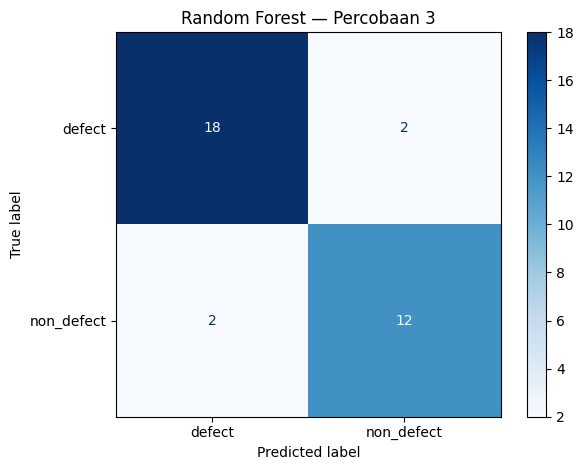

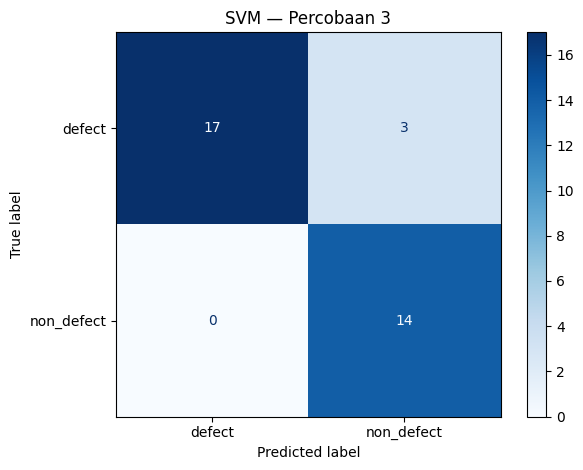

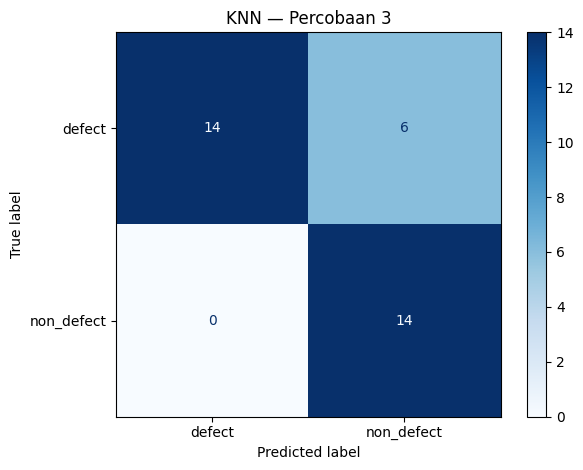

In [53]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_true))
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, rf.predict(X_test),  "Random Forest — Percobaan 3")
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM — Percobaan 3")
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN — Percobaan 3")

Pada percobaan 3, preprocessing tambahan berupa Sharpening dan Dilasi diterapkan setelah Median Filter dan Histogram Equalization. Sharpening menggunakan kernel Laplacian mempertajam tepi dan detail tekstur pada citra kain, sehingga perbedaan antara area cacat dan area normal menjadi lebih jelas. Dilasi kemudian memperluas area terang pada citra, yang dapat membuat fitur-fitur cacat seperti bintik atau bercak menjadi lebih menonjol dan mudah dideteksi oleh fitur GLCM.

Berdasarkan hasil klasifikasi, perlu dibandingkan apakah ketiga model (Random Forest, SVM, dan KNN) mengalami peningkatan akurasi, precision, recall, dan F1-Score dibandingkan dengan Percobaan 1 dan Percobaan 2. Dengan sharpening yang mempertajam tepi tekstur, fitur GLCM seperti contrast dan dissimilarity diharapkan menjadi lebih diskriminatif. Sementara dilasi yang memperluas area terang dapat membantu memperkuat pola cacat sehingga model dapat membedakan kelas defect dan non_defect dengan lebih baik.

Namun perlu diperhatikan bahwa sharpening dapat memperkuat noise yang tersisa setelah median filter, dan dilasi yang berlebihan dapat menyebabkan hilangnya detail halus pada tekstur kain. Oleh karena itu, hasil percobaan ini perlu dievaluasi secara menyeluruh untuk menentukan apakah kombinasi preprocessing yang lebih kompleks ini memberikan peningkatan performa yang signifikan atau justru menimbulkan efek negatif pada klasifikasi.